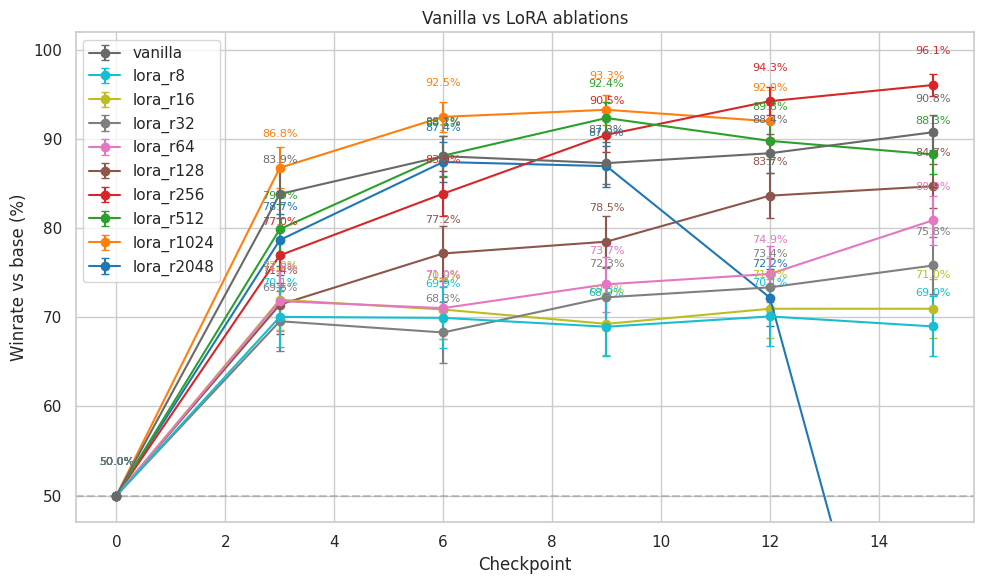

In [1]:
import json, re, seaborn as sns, matplotlib.pyplot as plt, pandas as pd, numpy as np
from pathlib import Path

rows = []
for p in Path("./eval_results").rglob("tldr_*.json"):
    d = json.load(open(p))
    model_a = d["meta"]["model_a"]
    m = re.search(r"lora[_-](\d+)", model_a)
    tag = f"lora_r{m.group(1)}" if m else "vanilla"
    ckpt = int(re.search(r"ckpt(\d+)", d["meta"]["run_name"]).group(1))
    met = d["metrics"]
    rows.append({"tag": tag, "ckpt": ckpt, "winrate": met["winrate_a_ignoring_ties"], "se": met["winrate_a_ignoring_ties_bootstrap_se"]})

df = pd.DataFrame(rows).sort_values(["tag", "ckpt"])
df = pd.concat([df] + [pd.DataFrame([{"tag": t, "ckpt": 0, "winrate": 50, "se": 0}]) for t in df.tag.unique()]).sort_values(["tag", "ckpt"])

tags = sorted(df.tag.unique(), key=lambda t: -int(re.search(r"(\d+)", t).group(1)) if "lora" in t else 1e9)
cmap = plt.colormaps["tab10"].resampled(len(tags) - 1)  # exclude vanilla from cmap
palette = {t: cmap(i) for i, t in enumerate(tags) if t != "vanilla"}
palette["vanilla"] = "dimgray"

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

tag_colors = {}
for tag, g in df.groupby("tag"):
    c = palette[tag]
    ax.errorbar(g.ckpt, g.winrate, yerr=g.se, label=tag, marker="o", capsize=3, color=c)
    tag_colors[tag] = c

ax.axhline(50, ls="--", c="gray", alpha=.4)
ax.set(xlabel="Checkpoint", ylabel="Winrate vs base (%)", title="Vanilla vs LoRA ablations")
ax.set_ylim(47, 102)

handles, labels = ax.get_legend_handles_labels()
order = sorted(range(len(labels)), key=lambda i: -1e9 if labels[i] == "vanilla" else int(re.search(r"(\d+)", labels[i]).group(1)))
ax.legend([handles[i] for i in order], [labels[i] for i in order])

for _, r in df.iterrows():
    c = tag_colors[r.tag]
    ax.annotate(f"{r.winrate:.1f}%", (r.ckpt, r.winrate), textcoords="offset points", xytext=(0, 22), ha="center", fontsize=8, color=c)
plt.tight_layout()

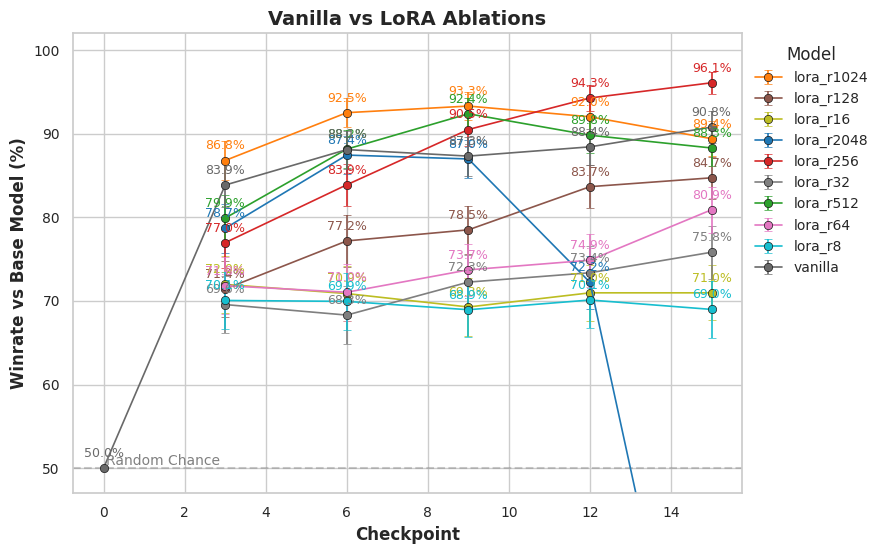

In [2]:
import json, re, seaborn as sns, matplotlib.pyplot as plt, pandas as pd, numpy as np
from pathlib import Path

# Load and process data with fixed vanilla baseline
rows = []
for p in Path("./eval_results").rglob("tldr_*.json"):
    d = json.load(open(p))
    model_a = d["meta"]["model_a"]
    m = re.search(r"lora[_-](\d+)", model_a)
    tag = f"lora_r{m.group(1)}" if m else "vanilla"
    ckpt = int(re.search(r"ckpt(\d+)", d["meta"]["run_name"]).group(1))
    met = d["metrics"]
    rows.append({"tag": tag, "ckpt": ckpt, "winrate": met["winrate_a_ignoring_ties"], "se": met["winrate_a_ignoring_ties_bootstrap_se"]})

# FIXED: Proper vanilla baseline addition
vanilla_entry = pd.DataFrame({"tag": ["vanilla"], "ckpt": [0], "winrate": [50], "se": [0]})
df = pd.concat([pd.DataFrame(rows), vanilla_entry]).sort_values(["tag", "ckpt"])

# Prepare tags order
tags = sorted(df.tag.unique(), key=lambda t: -int(re.search(r"(\d+)", t).group(1)) if "lora" in t else 1e9)

# Improved color palette
cmap = plt.colormaps["tab10"].resampled(len(tags) - 1)
palette = {t: cmap(i) for i, t in enumerate(tags) if t != "vanilla"}
palette["vanilla"] = "dimgray"

# Set improved font settings
plt.rcParams.update({
    "font.size": 12,
    "axes.labelweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# Create figure with better layout
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")

# Plot with enhanced styling
for tag, group in df.groupby("tag"):
    color = palette[tag]
    ax.errorbar(
        group.ckpt, group.winrate, yerr=group.se,
        label=tag, 
        marker="o", markersize=6,
        markerfacecolor=color, markeredgecolor="k", markeredgewidth=0.5,
        capsize=3, linewidth=1.2, color=color
    )

# Add reference line with label
ax.axhline(50, ls="--", c="gray", alpha=0.4)
ax.text(0.05, 50, "Random Chance", ha="left", va="bottom", fontsize=10, color="gray")

# Cleaner annotations
for _, row in df.iterrows():
    ax.annotate(
        f"{row.winrate:.1f}%",
        (row.ckpt, row.winrate),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        color=row.tag_colors[row.tag] if hasattr(row, 'tag_colors') else palette[row.tag]
    )

# Final styling
ax.set_xlabel("Checkpoint", fontsize=12, fontweight="bold")
ax.set_ylabel("Winrate vs Base Model (%)", fontsize=12, fontweight="bold")
ax.set_title("Vanilla vs LoRA Ablations", fontsize=14, fontweight="bold")
ax.set_ylim(47, 102)

# Improved legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    loc="upper left", 
    bbox_to_anchor=(1, 1),
    fontsize=10,
    title="Model",
    ncol=1,
    frameon=False
)

# Final layout adjustments
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(right=0.75)  # Make space for legend
plt.show()


In [ ]:
# with Qwen/Qwen3.5-4B we have "hidden_size": 2560 so r=2048 is already a bit ridiculous